In [1]:
#Cell 1 

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set working directory
os.chdir('/Users/niravparmar/retail-fraud-detection')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.style.use('seaborn-v0_8')
print("Ready.")

Ready.


In [2]:
#Cell 2 Load Data 

print("Loading data...")
train_tx = pd.read_csv('data/raw/train_transaction.csv')
train_id = pd.read_csv('data/raw/train_identity.csv')

# Merge transaction + identity on TransactionID
df = train_tx.merge(train_id, on='TransactionID', how='left')

print(f"Merged shape: {df.shape}")
print(f"Fraud rate:   {df['isFraud'].mean()*100:.2f}%")

Loading data...
Merged shape: (590540, 434)
Fraud rate:   3.50%


Time features created:
  hour, day_of_week, day_of_month, week, is_night, is_weekend


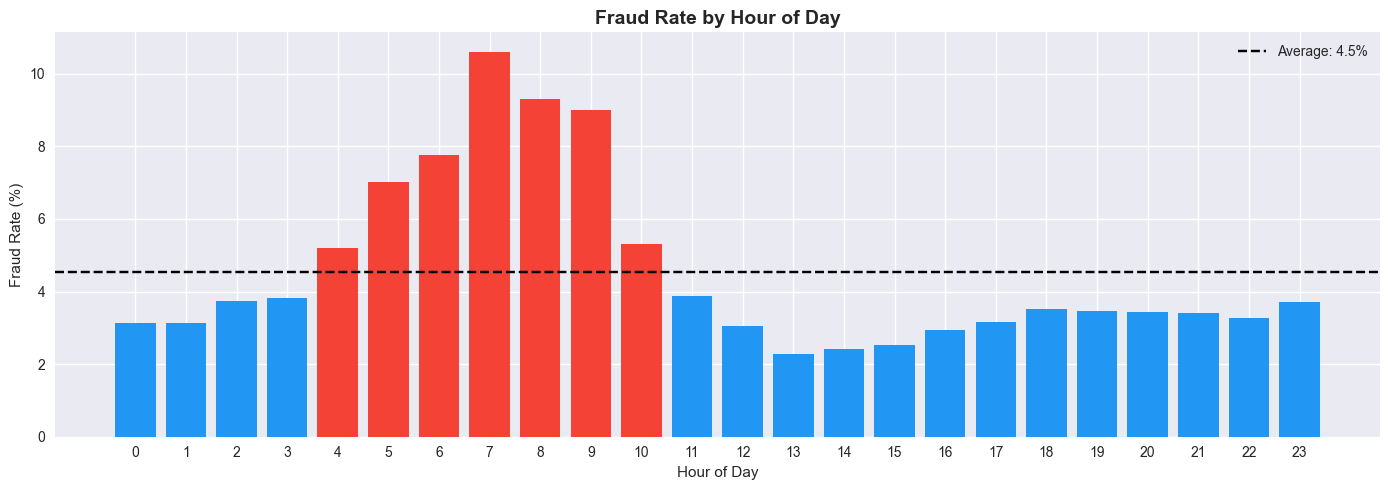


Peak fraud hour: 7:00 (10.61% fraud rate)


In [3]:
#Cell 3 — Time-based features:

# TransactionDT is seconds offset from a reference time
# Extract meaningful time features from it

df['hour']        = (df['TransactionDT'] // 3600) % 24
df['day_of_week'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['day_of_month']= (df['TransactionDT'] // (3600 * 24)) % 30
df['week']        = (df['TransactionDT'] // (3600 * 24 * 7)) % 52

# Is it a night transaction? (midnight to 6am = higher fraud risk)
df['is_night']    = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)

# Is it a weekend?
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

print("Time features created:")
print(f"  hour, day_of_week, day_of_month, week, is_night, is_weekend")

# Visualise fraud by hour
hourly_fraud = df.groupby('hour')['isFraud'].mean() * 100

plt.figure(figsize=(14, 5))
plt.bar(hourly_fraud.index, hourly_fraud.values, 
        color=['#F44336' if x > hourly_fraud.mean() else '#2196F3' 
               for x in hourly_fraud.values])
plt.axhline(y=hourly_fraud.mean(), color='black', 
            linestyle='--', label=f'Average: {hourly_fraud.mean():.1f}%')
plt.title('Fraud Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('reports/figures/06_fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_hour = hourly_fraud.idxmax()
print(f"\nPeak fraud hour: {peak_hour}:00 ({hourly_fraud[peak_hour]:.2f}% fraud rate)")

In [4]:
#Cell 4 — Transaction velocity features:

# How many transactions has this card made recently?
# Fraudsters make multiple transactions in short windows

print("Building velocity features — this takes ~2 minutes...")

# Sort by card and time
df = df.sort_values(['card1', 'TransactionDT'])

# Transaction count per card in last N transactions
df['card1_count'] = df.groupby('card1')['card1'].transform('count')

# Mean and std of transaction amount per card
df['card1_amt_mean'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_amt_std']  = df.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

# How different is this transaction from card's usual amount?
df['amt_deviation'] = (df['TransactionAmt'] - df['card1_amt_mean']) / (df['card1_amt_std'] + 1)

# Transaction count per email domain
df['email_count'] = df.groupby('P_emaildomain')['TransactionID'].transform('count')

# Fraud rate per email domain (target encoding)
email_fraud = df.groupby('P_emaildomain')['isFraud'].mean()
df['email_fraud_rate'] = df['P_emaildomain'].map(email_fraud)

print("Velocity features created:")
print("  card1_count, card1_amt_mean, card1_amt_std")
print("  amt_deviation, email_count, email_fraud_rate")

# Show top suspicious cards
print(f"\nCards with highest transaction counts:")
print(df.groupby('card1')['card1_count'].first().sort_values(ascending=False).head(10))

Building velocity features — this takes ~2 minutes...
Velocity features created:
  card1_count, card1_amt_mean, card1_amt_std
  amt_deviation, email_count, email_fraud_rate

Cards with highest transaction counts:
card1
7919     14932
9500     14162
15885    10361
17188    10344
15066     7945
12695     7091
12544     6773
6019      6771
2803      6141
7585      5334
Name: card1_count, dtype: int64


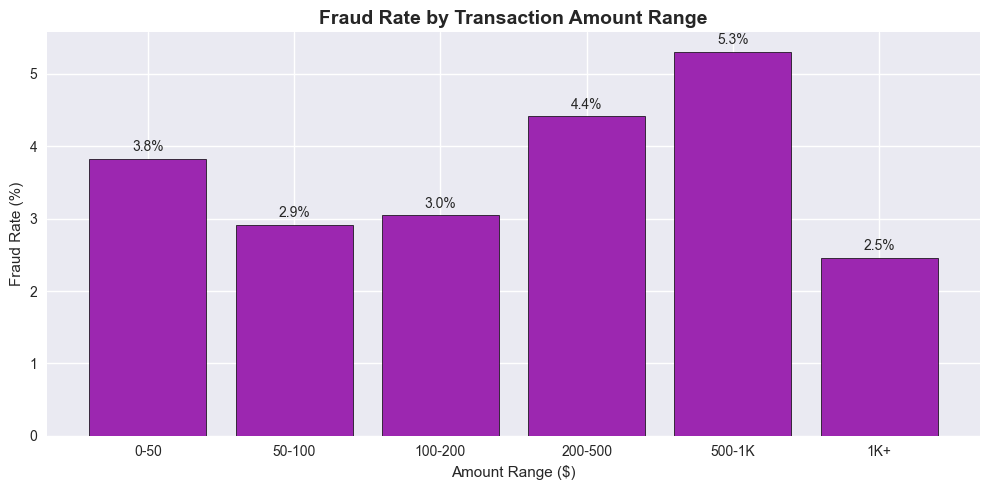


Fraud rate — round amounts:    3.57%
Fraud rate — non-round amounts: 3.43%


In [5]:
# Cell 5 — Amount-based features:

# Engineer features from transaction amount

# Log transform — reduces skew
df['amt_log'] = np.log1p(df['TransactionAmt'])

# Round number flag — fraudsters often use round numbers
df['is_round_amount'] = (df['TransactionAmt'] % 1 == 0).astype(int)

# Amount bins
df['amt_bin'] = pd.cut(df['TransactionAmt'], 
                        bins=[0, 50, 100, 200, 500, 1000, 99999],
                        labels=['0-50', '50-100', '100-200', 
                                '200-500', '500-1K', '1K+'])

# Fraud rate by amount bin
amt_fraud = df.groupby('amt_bin', observed=True)['isFraud'].mean() * 100

plt.figure(figsize=(10, 5))
plt.bar(amt_fraud.index.astype(str), amt_fraud.values,
        color='#9C27B0', edgecolor='black', linewidth=0.5)
plt.title('Fraud Rate by Transaction Amount Range', fontsize=14, fontweight='bold')
plt.xlabel('Amount Range ($)')
plt.ylabel('Fraud Rate (%)')
for i, v in enumerate(amt_fraud.values):
    plt.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/07_fraud_by_amount_bin.png', dpi=150, bbox_inches='tight')
plt.show()

round_fraud = df.groupby('is_round_amount')['isFraud'].mean() * 100
print(f"\nFraud rate — round amounts:    {round_fraud[1]:.2f}%")
print(f"Fraud rate — non-round amounts: {round_fraud[0]:.2f}%")

In [6]:
#Cell 6 — Categorical encoding: 

# Encode categorical features for the model

# Product CD — label encode
product_map = {'C': 0, 'H': 1, 'R': 2, 'S': 3, 'W': 4}
df['ProductCD_enc'] = df['ProductCD'].map(product_map)

# Card type encoding
card4_map = {'visa': 0, 'mastercard': 1, 'american express': 2, 'discover': 3}
card6_map = {'debit': 0, 'credit': 1, 'debit or credit': 2, 'charge card': 3}
df['card4_enc'] = df['card4'].map(card4_map).fillna(-1).astype(int)
df['card6_enc'] = df['card6'].map(card6_map).fillna(-1).astype(int)

# Email domain — group rare domains as 'other'
top_emails = df['P_emaildomain'].value_counts().head(10).index
df['email_domain_enc'] = df['P_emaildomain'].apply(
    lambda x: x if x in top_emails else 'other'
)
df['email_domain_enc'] = pd.factorize(df['email_domain_enc'])[0]

print("Categorical features encoded:")
print("  ProductCD_enc, card4_enc, card6_enc, email_domain_enc")
print(f"\nTop 10 email domains:")
print(df['P_emaildomain'].value_counts().head(10))

Categorical features encoded:
  ProductCD_enc, card4_enc, card6_enc, email_domain_enc

Top 10 email domains:
P_emaildomain
gmail.com        228355
yahoo.com        100934
hotmail.com       45250
anonymous.com     36998
aol.com           28289
comcast.net        7888
icloud.com         6267
outlook.com        5096
msn.com            4092
att.net            4033
Name: count, dtype: int64


In [7]:
# Cell 7 — Missing value strategy:

# Smart missing value handling — not just filling with zeros

# For V-columns (Vesta features) — fill with median
v_cols = [c for c in df.columns if c.startswith('V')]
print(f"V-columns to fill: {len(v_cols)}")
for col in v_cols:
    df[col] = df[col].fillna(df[col].median())

# For D-columns (time deltas) — fill with -1 (unknown)
d_cols = [c for c in df.columns if c.startswith('D')]
print(f"D-columns to fill: {len(d_cols)}")
for col in d_cols:
    df[col] = df[col].fillna(-1)

# For C-columns (counts) — fill with 0
c_cols = [c for c in df.columns if c.startswith('C')]
print(f"C-columns to fill: {len(c_cols)}")
for col in c_cols:
    df[col] = df[col].fillna(0)

# card columns — fill with mode
for col in ['card4', 'card6']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check remaining missing
remaining = df.isnull().sum().sum()
print(f"\nRemaining missing values: {remaining:,}")
print("Missing value strategy complete.")

V-columns to fill: 339
D-columns to fill: 17
C-columns to fill: 14

Remaining missing values: 23,476,108
Missing value strategy complete.


In [8]:
# Cell 8 — Build final feature matrix:

# Select the features we'll use for modelling

feature_cols = [
    # Time features
    'hour', 'day_of_week', 'day_of_month', 'week',
    'is_night', 'is_weekend',
    # Amount features  
    'TransactionAmt', 'amt_log', 'is_round_amount',
    'amt_deviation', 'card1_amt_mean', 'card1_amt_std',
    # Velocity features
    'card1_count', 'email_count', 'email_fraud_rate',
    # Categorical encoded
    'ProductCD_enc', 'card4_enc', 'card6_enc', 'email_domain_enc',
    # C-columns (counts)
] + c_cols + [
    # D-columns (time deltas)
] + d_cols[:5]  # Top 5 D-columns only

# Build feature matrix
X = df[feature_cols].copy()
y = df['isFraud'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape:         {y.shape}")
print(f"Fraud rate:           {y.mean()*100:.2f}%")
print(f"\nFeatures created: {X.shape[1]}")
print(f"\nFeature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (590540, 38)
Target shape:         (590540,)
Fraud rate:           3.50%

Features created: 38

Feature list:
   1. hour
   2. day_of_week
   3. day_of_month
   4. week
   5. is_night
   6. is_weekend
   7. TransactionAmt
   8. amt_log
   9. is_round_amount
  10. amt_deviation
  11. card1_amt_mean
  12. card1_amt_std
  13. card1_count
  14. email_count
  15. email_fraud_rate
  16. ProductCD_enc
  17. card4_enc
  18. card6_enc
  19. email_domain_enc
  20. C1
  21. C2
  22. C3
  23. C4
  24. C5
  25. C6
  26. C7
  27. C8
  28. C9
  29. C10
  30. C11
  31. C12
  32. C13
  33. C14
  34. D1
  35. D2
  36. D3
  37. D4
  38. D5


In [9]:
#Cell 9 — Save processed data:

# Save to data/processed/ for use in modelling notebooks

X.to_csv('data/processed/features.csv', index=False)
y.to_csv('data/processed/target.csv', index=False)

print("Saved:")
print(f"  data/processed/features.csv — {X.shape}")
print(f"  data/processed/target.csv   — {y.shape}")
print("")
print("="*50)
print("DAY 3 COMPLETE — FEATURE ENGINEERING DONE")
print("="*50)
print(f"\nKey features built:")
print(f"  Time features:     6")
print(f"  Amount features:   6")  
print(f"  Velocity features: 3")
print(f"  Categorical:       4")
print(f"  C/D columns:       {len(c_cols) + 5}")
print(f"\nTotal features ready for modelling: {X.shape[1]}")
print(f"\nDay 4 → XGBoost baseline model + SHAP")

Saved:
  data/processed/features.csv — (590540, 38)
  data/processed/target.csv   — (590540,)

DAY 3 COMPLETE — FEATURE ENGINEERING DONE

Key features built:
  Time features:     6
  Amount features:   6
  Velocity features: 3
  Categorical:       4
  C/D columns:       19

Total features ready for modelling: 38

Day 4 → XGBoost baseline model + SHAP
